Leer los archivos csv

In [25]:
import csv
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


ruta_movies = Path(r'DataSets\\tmdb_5000_movies.csv')
df_movies = pd.read_csv(ruta_movies)
print('Encabezado y primeras 5 filas:')
print(df_movies.head())
print('\nDescripcion general:')
print(df_movies.describe())
print('\nInformacion de columnas:')
print(df_movies.info())

print("Nulos en df_movies:")
print(df_movies.isnull().sum())

#with ruta_movies.open('r', newline='', encoding='utf-8') as f:
    #reader = csv.reader(f)
    #encabezado = next(reader)
    #print('Encabezado: ', encabezado)
    #for fila in reader:
        #print('Fila', fila)

Encabezado y primeras 5 filas:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...           

In [26]:
ruta_credits = Path(r'DataSets\\tmdb_5000_credits.csv')

df_credits = pd.read_csv(ruta_credits)
print('\nEncabezado y primeras 5 filas de creditos:')
print(df_credits.head())

print("\nNulos en df_credits:")
print(df_credits.isnull().sum())


#with ruta_credits.open('r', newline='', #encoding='utf-8') as f:
    #reader = csv.reader(f)
    #encabezado = next(reader)
    #print('Encabezado: ', encabezado)
    #for fila in reader:
        #print('Fila', fila)


Encabezado y primeras 5 filas de creditos:
   movie_id                                     title  \
0     19995                                    Avatar   
1       285  Pirates of the Caribbean: At World's End   
2    206647                                   Spectre   
3     49026                     The Dark Knight Rises   
4     49529                               John Carter   

                                                cast  \
0  [{"cast_id": 242, "character": "Jake Sully", "...   
1  [{"cast_id": 4, "character": "Captain Jack Spa...   
2  [{"cast_id": 1, "character": "James Bond", "cr...   
3  [{"cast_id": 2, "character": "Bruce Wayne / Ba...   
4  [{"cast_id": 5, "character": "John Carter", "c...   

                                                crew  
0  [{"credit_id": "52fe48009251416c750aca23", "de...  
1  [{"credit_id": "52fe4232c3a36847f800b579", "de...  
2  [{"credit_id": "54805967c3a36829b5002c41", "de...  
3  [{"credit_id": "52fe4781c3a36847f81398c3", "de...  
4

In [27]:
print("\nNulos en df_credits:")
print(df_credits.isnull().sum())

print("Nulos en df_movies:")
print(df_movies.isnull().sum())


Nulos en df_credits:
movie_id    0
title       0
cast        0
crew        0
dtype: int64
Nulos en df_movies:
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64


In [28]:
#Como solo el csv de peliculas tiene nulos, no encargaremos de aquellos y crearemos un nuevo csv sin errores.
df_movies = df_movies.drop(columns=['homepage', 'tagline'], errors='ignore')  # errors='ignore' por si alguna no existe

# Verificar las columnas restantes
print("Columnas después de eliminación:")
print(df_movies.columns)

# Guardar el DataFrame modificado en un nuevo CSV
ruta_nuevo = Path('nuevosDatasets/tmdb_5000_movies_limpia.csv')
df_movies.to_csv(ruta_nuevo, index=False)  # index=False para no incluir el índice como columna

print(f"Archivo guardado en: {ruta_nuevo}")


#Se remueven
df_movies['release_date'] = pd.to_datetime(df_movies['release_date'], errors='coerce')

# Eliminar filas donde release_date es null (NaT)
df_movies = df_movies.dropna(subset=['release_date'])

# Eliminar filas donde runtime es null (NaN)
df_movies = df_movies.dropna(subset=['runtime'])

# Imputar null en overview con "Sin overview"
df_movies['overview'] = df_movies['overview'].fillna("Sin overview")

# Verificar nulos restantes en estas columnas
print("Nulos después del tratamiento:")
print(df_movies[['release_date', 'runtime', 'overview']].isnull().sum())

# Verificar el número de películas restantes
print(f"Número de películas después de eliminación: {len(df_movies)}")

# Guardar el DataFrame actualizado en el CSV
ruta_nuevo = Path('nuevosDatasets/tmdb_5000_movies_clean.csv')
df_movies.to_csv(ruta_nuevo, index=False)

print(f"Archivo actualizado guardado en: {ruta_nuevo}")



Columnas después de eliminación:
Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'title', 'vote_average', 'vote_count'],
      dtype='object')
Archivo guardado en: nuevosDatasets\tmdb_5000_movies_limpia.csv
Nulos después del tratamiento:
release_date    0
runtime         0
overview        0
dtype: int64
Número de películas después de eliminación: 4800
Archivo actualizado guardado en: nuevosDatasets\tmdb_5000_movies_clean.csv


Resumen de df_movies:
             budget             id   popularity  \
count  4.803000e+03    4803.000000  4803.000000   
mean   2.904504e+07   57165.484281    21.492301   
min    0.000000e+00       5.000000     0.000000   
25%    7.900000e+05    9014.500000     4.668070   
50%    1.500000e+07   14629.000000    12.921594   
75%    4.000000e+07   58610.500000    28.313505   
max    3.800000e+08  459488.000000   875.581305   
std    4.072239e+07   88694.614033    31.816650   

                        release_date       revenue      runtime  vote_average  \
count                           4802  4.803000e+03  4801.000000   4803.000000   
mean   2002-12-27 23:45:54.352353280  8.226064e+07   106.875859      6.092172   
min              1916-09-04 00:00:00  0.000000e+00     0.000000      0.000000   
25%              1999-07-14 00:00:00  0.000000e+00    94.000000      5.600000   
50%              2005-10-03 00:00:00  1.917000e+07   103.000000      6.200000   
75%              2011-02-16 00:0

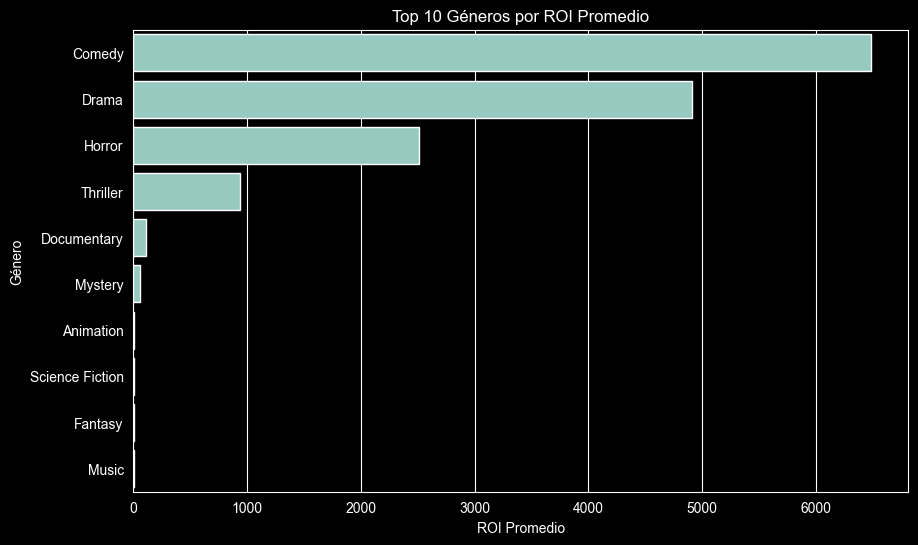

Correlación Pearson entre budget y vote_average: 0.09314574534816406


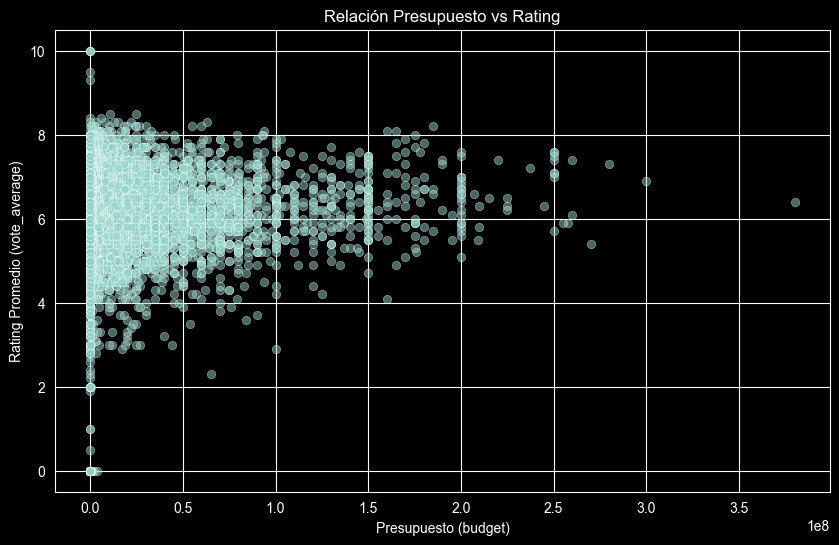

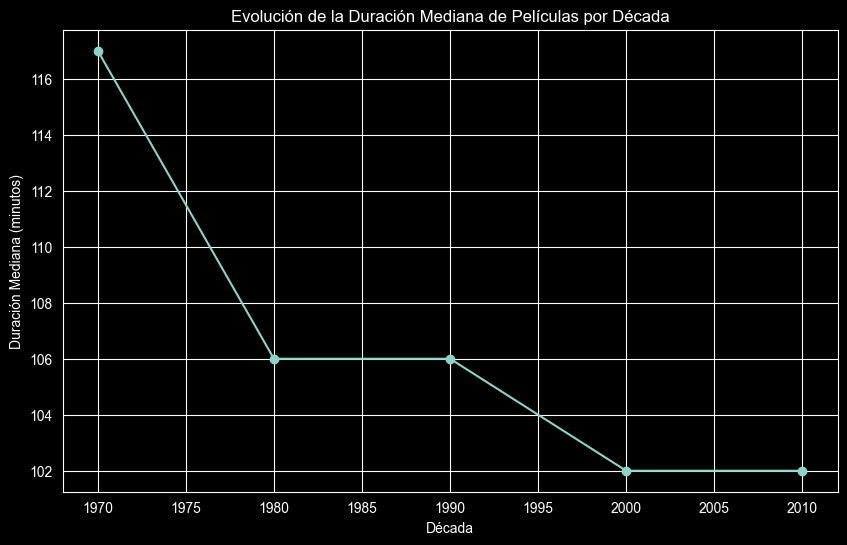

In [33]:
rutaLimpio = Path("nuevosDatasets/tmdb_5000_movies_limpia.csv")
moviesLimpio = pd.read_csv(rutaLimpio)

# --- AGREGA ESTA LÍNEA PARA CORREGIR EL ERROR ---
moviesLimpio['release_date'] = pd.to_datetime(moviesLimpio['release_date'])
# ------------------------------------------------

# Resumen inicial de df_movies
print("Resumen de df_movies:")
print(moviesLimpio.describe())  # Estadísticas numéricas (media, mediana, etc.)
print(moviesLimpio.info())  # Tipos y nulos
print(moviesLimpio.head())  # Primeras filas

# Resumen inicial de df_credits
print("\nResumen de df_credits:")
print(df_credits.describe())
print(df_credits.info())
print(df_credits.head())

### Eje 1: Rentabilidad (ROI) por género o país
# ROI = revenue / budget (evitar divisiones por 0)
moviesLimpio['ROI'] = np.where(moviesLimpio['budget'] > 0, moviesLimpio['revenue'] / moviesLimpio['budget'], np.nan)

# Parsear 'genres' de string JSON a lista real
import ast  # Para parsear strings JSON-like
moviesLimpio['genres_list'] = moviesLimpio['genres'].apply(lambda x: [g['name'] for g in ast.literal_eval(x)] if isinstance(x, str) else [])

# Explotar géneros para análisis
genres_exploded = moviesLimpio.explode('genres_list')

# ROI promedio por género
roi_por_genero = genres_exploded.groupby('genres_list')['ROI'].mean().sort_values(ascending=False).head(10)

# Gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=roi_por_genero.values, y=roi_por_genero.index)
plt.title('Top 10 Géneros por ROI Promedio')
plt.xlabel('ROI Promedio')
plt.ylabel('Género')
plt.show()

# Conclusión: Los géneros como [ej: Horror] tienen alto ROI porque son baratos de producir y generan buena taquilla. Exportamos a CSV.
roi_por_genero.to_csv('nuevosDatasets/roi_por_genero.csv', index=True)

### Eje 2: Relación entre presupuesto y rating
# Correlación Pearson
correlacion = moviesLimpio['budget'].corr(moviesLimpio['vote_average'])
print(f"Correlación Pearson entre budget y vote_average: {correlacion}")

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=moviesLimpio, x='budget', y='vote_average', alpha=0.5)
plt.title('Relación Presupuesto vs Rating')
plt.xlabel('Presupuesto (budget)')
plt.ylabel('Rating Promedio (vote_average)')
plt.show()

# Conclusión: Hay una correlación baja positiva ({correlacion}), indicando que más presupuesto no garantiza mejor rating, pero hay outliers con alto budget y rating.

### Eje 3: Evolución de la duración de películas en los últimos 50 años
# Crear columna 'release_year' a partir de 'release_date' (asumiendo que ya es datetime de celdas anteriores)
moviesLimpio['release_year'] = moviesLimpio['release_date'].dt.year  # Extraer el año como entero

# Filtrar últimos 50 años (asumiendo current_date ~2025)
df_recent = moviesLimpio[moviesLimpio['release_year'] >= 1975].copy()

# Duración promedio por década
df_recent['decada'] = (df_recent['release_year'] // 10) * 10
duracion_por_decada = df_recent.groupby('decada')['runtime'].median()

# Gráfico
plt.figure(figsize=(10, 6))
duracion_por_decada.plot(kind='line', marker='o')
plt.title('Evolución de la Duración Mediana de Películas por Década')
plt.xlabel('Década')
plt.ylabel('Duración Mediana (minutos)')
plt.show()

# Conclusión: La duración ha aumentado ligeramente en las últimas décadas, posiblemente por blockbusters más largos. Exportamos a JSON.
duracion_por_decada.to_json('nuevosDatasets/duracion_por_decada.json', orient='index')

### Conclusiones Generales del EDA
# - El dataset tiene ~4800 películas, con presupuestos variando de 0 a cientos de millones.
# - Patrones clave: [resumir hallazgos de los ejes].
# - Para la API, usaremos los archivos generados (e.g., roi_por_genero.csv) en endpoints como /top_generos.